# Incremental Capstone Unit 2

**Instructor:** Abishek Ganesh

**Your Name:** Kalpana Ms master of Engg

  
**Your Role:** Data Scientist  
**Client:** ShopSmart (a growing retail chain)  
**Due Date:** January 19th, 2025

---

## Project Brief

Welcome to your **Incremental Capstone Unit 2**! ShopSmart was so impressed with your Python tools from Unit 1 that they've hired you again. This time, they have a much larger challenge: a messy sales dataset with **500 transactions** that needs to be cleaned, explored, and prepared for their upcoming machine learning initiative.

Your mission is to transform this raw, messy data into a clean, ML-ready dataset. The data science team will use your prepared data in Unit 3 to build predictive models.

### The Data Problems You'll Face
- **Missing values** in several columns
- **Duplicate transactions** that slipped through their system
- **Messy text** with inconsistent spacing and capitalization
- **Outliers** that look like data entry errors
- **Categorical columns** that need to be converted to numbers for ML
- **Different scales** across numeric columns

---

### Rules & Integrity
1.  **NO AI TOOLS**: You may **NOT** use ChatGPT, Claude, Gemini, or any other AI assistant to generate code for this assignment. The goal is to build *your* fundamental skills. If you rely on AI now, the advanced topics later will be impossible.
2.  **Study Groups Encouraged**: You **ARE** encouraged to discuss ideas, pitch solutions, and explain concepts to your study group peers. Teaching others is the best way to learn! However, the code you submit must be **your own**.
3.  **Use Your Resources**: You are free to use Google, StackOverflow, Pandas documentation, and your class notes.
4.  **Comment Your Code**: You must include comments explaining *why* you are doing what you are doing. I want to see your thought process.
5.  **Submission**: You may submit this assignment multiple times for feedback before the deadline.

### How to Verify Your Work
- **Assert Tests**: I have provided `assert` statements to help you check your work. Your code should pass all of them.
- **Example Outputs**: Each section shows expected outputs. Compare yours to make sure you're on track.
- **Written Reflections**: Answer all reflection questions - they help me understand your thinking.

---

## Setup: Import Libraries

Run this cell first to import all the libraries you'll need.

In [ ]:
# Required imports - run this cell first!
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Display settings
pd.set_option('display.max_columns', None)
%matplotlib inline

print("Libraries loaded successfully!")

Libraries loaded successfully!


---

## Part 1: Problem Definition

Before diving into the data, take a moment to think about what you're trying to accomplish.

### Written Reflection
> **Please answer the questions below. They are a required part of the assignment!**

**Question 1:** What is the main goal of this capstone? What will the data science team use your cleaned data for?

**Question 2:** Why can't we just feed the raw CSV file directly into a machine learning model? List at least 3 problems that would occur.

*(Double-click here to write your answers)*

**Answer 1:** The main goal of this Capstone Project is to transform the raw, messy Shopsmart sales data into a clean, ML-ready dataset. The data science team will use cleaned and prepared data to build predictive models.

**Answer 2:** If we feed raw CSV files directly to machine learning model then the output results will be inaccurate.

Here are the list of at least 3 problems that would occur:

1. Data quality issues like missing null values, incorrectly formatted strings or outliers in raw CSV file will cause ML model to output biased results or inaccuracies.

2. ML models will not work properly when raw CSV file has categorical variables with string data type because ML model works with encoded numbers.

3. Raw CSV file has numeric columns with different types of range values; for example one column ranges from 10 to 100, while another ranges from 1 to 2000. This will confuse ML model without scaling these numeric columns.

---

## Part 2: Data Loading

**The Problem:** ShopSmart has given you their sales data in a CSV file. Your first task is to load it and take an initial look.

**Your Task:** Create a function that loads the data and returns a DataFrame.

### Example Verification
```python
df = load_sales_data('shopsmart_sales.csv')
print(df.shape)  # Should print (500, 13)
```

In [ ]:
def load_sales_data(filepath):
    """
    Load sales data from a CSV file.

    Args:
        filepath (str): Path to the CSV file

    Returns:
        pd.DataFrame: The loaded data
    """
    # Your code here
    df = pd.read_csv(filepath)
    return df

In [ ]:
# ============================================================
# ⚠️  DO NOT MODIFY THIS CELL - VERIFICATION TESTS ONLY  ⚠️
# Just run this cell to check if your code is working.
# Hidden test cases depend on this exact structure.
# ============================================================

# Load the data
df = load_sales_data('shopsmart_sales.csv')

# Basic Verification
assert df is not None, "Function returned None - did you forget to return the DataFrame?"
assert isinstance(df, pd.DataFrame), "Function should return a pandas DataFrame"
assert df.shape == (500, 13), f"Expected shape (500, 13), got {df.shape}"
print("[PASS] Part 2 Tests Passed!")
print(f"\nDataset loaded: {df.shape[0]} rows, {df.shape[1]} columns")

[PASS] Part 2 Tests Passed!

Dataset loaded: 500 rows, 13 columns


In [ ]:
# Take a first look at the data
df.head(10)

,transaction_id,customer_id,date,product_category,product_name,quantity,unit_price,total_amount,payment_method,store_location,customer_age,is_member,customer_tier
0,1165,109,2024-08-24,Home & Garden,plant pot,4,133.08,532.32,Credit Card,Mall,29.0,Yes,Bronze
1,1384,127,2024-03-01,Electronics,Headphones,3,257.78,773.34,Debit Card,Suburb,68.0,Yes,Platinum
2,1046,211,2024-11-27,Clothing,jeans,1,261.80,261.80,Credit Card,Suburb,34.0,No,Silver
3,1157,188,2024-03-19,Electronics,Smart Watch,4,292.36,1169.44,Credit Card,Mall,53.0,Yes,Silver
4,1054,180,2024-09-12,Electronics,tablet,3,289.74,869.22,Credit Card,Downtown,22.0,Yes,Bronze
5,1073,211,2024-05-29,Sports,Tennis Racket,1,225.66,225.66,Cash,Airport,54.0,Yes,Bronze
6,1316,230,2024-09-17,Clothing,jeans,2,198.61,397.22,Mobile Payment,Online,70.0,No,Bronze
7,1210,129,2024-12-27,Home & Garden,Lamp,5,387.31,1936.55,Cash,Online,32.0,No,Gold
8,1075,198,2024-05-19,Home & Garden,PILLOW,1,296.35,296.35,Credit Card,Suburb,34.0,Yes,Silver
9,1334,247,2024-07-31,Home & Garden,Lamp,1,252.73,252.73,Debit Card,Mall,44.0,Yes,Silver


In [ ]:
# Check the data types and missing values
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   transaction_id    500 non-null    int64  
 1   customer_id       500 non-null    int64  
 2   date              500 non-null    object 
 3   product_category  500 non-null    object 
 4   product_name      500 non-null    object 
 5   quantity          500 non-null    int64  
 6   unit_price        475 non-null    float64
 7   total_amount      475 non-null    float64
 8   payment_method    500 non-null    object 
 9   store_location    460 non-null    object 
 10  customer_age      485 non-null    float64
 11  is_member         500 non-null    object 
 12  customer_tier     500 non-null    object 
dtypes: float64(3), int64(3), object(7)
memory usage: 50.9+ KB


### Written Reflection
> **Please answer the question below. It is a required part of the assignment!**

**Question:** Looking at the output of `df.info()`, what problems do you already notice with this data? (Hint: Look at non-null counts and data types)

**Answer:** Looking at the output of df.info(), I see there are 3 numerical columns (unit_price, total_amount, customer_age) and 1 categorical column (store_location) are having non-null counts less than total entries (500). This indicates those columns have missing values.

---

## Part 3: Data Quality Assessment

**The Problem:** Before cleaning, we need to know exactly what's wrong with the data. ShopSmart's manager wants a summary report.

**Your Task:** Create a function that analyzes the data and returns a quality report.

### Example Verification
```python
report = check_data_quality(df)
print(report['total_missing'])     # Should be > 0
print(report['duplicate_count'])   # Should be 15
```

In [ ]:
def check_data_quality(df):
    """
    Analyze data quality and return a summary report.

    Args:
        df (pd.DataFrame): The DataFrame to analyze

    Returns:
        dict: A dictionary containing:
            - 'total_rows': Total number of rows
            - 'total_columns': Total number of columns
            - 'missing_by_column': Dict of {column: missing_count}
            - 'total_missing': Total missing values across all columns
            - 'duplicate_count': Number of duplicate rows (based on transaction_id)
            - 'data_types': Dict of {column: dtype}
    """
    total_rows = df.shape[0]
    total_columns = df.shape[1]
    missing_by_column = df.isna().sum()
    total_missing = missing_by_column.sum()
    duplicate_count = df.duplicated(subset=['transaction_id']).sum()
    data_types = df.dtypes.apply(str).to_dict()

    report = {
        'total_rows': total_rows,
        'total_columns': total_columns,
        'missing_by_column': missing_by_column.to_dict(),
        'total_missing': total_missing,
        'duplicate_count': duplicate_count,
        'data_types': data_types,
    }

    return report

In [ ]:
# ============================================================
# ⚠️  DO NOT MODIFY THIS CELL - VERIFICATION TESTS ONLY  ⚠️
# Just run this cell to check if your code is working.
# Hidden test cases depend on this exact structure.
# ============================================================

# Run the quality check
report = check_data_quality(df)

# Basic Verification
assert report is not None, "Function returned None"
assert isinstance(report, dict), "Function should return a dictionary"
assert 'total_rows' in report, "Missing 'total_rows' key"
assert 'missing_by_column' in report, "Missing 'missing_by_column' key"
assert 'duplicate_count' in report, "Missing 'duplicate_count' key"
assert report['total_rows'] == 500, f"Expected 500 rows, got {report['total_rows']}"
assert report['duplicate_count'] == 15, f"Expected 15 duplicates, got {report['duplicate_count']}"
assert report['total_missing'] > 0, "There should be missing values in this dataset"
print("[PASS] Part 3 Tests Passed!")

# Display the report
print("\n=== DATA QUALITY REPORT ===")
print(f"Total Rows: {report['total_rows']}")
print(f"Total Columns: {report['total_columns']}")
print(f"Duplicate Transactions: {report['duplicate_count']}")
print(f"Total Missing Values: {report['total_missing']}")
print("\nMissing by Column:")
for col, count in report['missing_by_column'].items():
    if count > 0:
        print(f"  - {col}: {count}")

[PASS] Part 3 Tests Passed!

=== DATA QUALITY REPORT ===
Total Rows: 500
Total Columns: 13
Duplicate Transactions: 15
Total Missing Values: 105

Missing by Column:
  - unit_price: 25
  - total_amount: 25
  - store_location: 40
  - customer_age: 15


---

## Part 4: Data Cleaning

**The Problem:** Now we need to fix all the issues we found. This is the most critical step!

**Your Task:** Create a function that:
1. Removes duplicate transactions (keep the first occurrence)
2. Handles missing values appropriately:
   - For numeric columns: fill with the **median**
   - For categorical columns: fill with the **mode** (most common value)
3. Cleans the `product_name` column (strip whitespace, convert to lowercase)
4. Removes outliers in `customer_age` (keep only ages between 10 and 100)

### Example Verification
```python
df_clean = clean_data(df)
print(df_clean.shape)                    # Should be less than (500, 12) - duplicates removed
print(df_clean.isnull().sum().sum())     # Should be 0 - no missing values
print(df_clean['product_name'].iloc[0])  # Should be lowercase with no extra spaces
```

In [ ]:
def clean_data(df):
    """
    Clean the sales data.

    Steps:
    1. Remove duplicate transactions (based on transaction_id)
    2. Fill missing numeric values with median
    3. Fill missing categorical values with mode
    4. Clean product_name (strip whitespace, lowercase)
    5. Remove outliers in customer_age (keep 10-100)

    Args:
        df (pd.DataFrame): The raw DataFrame

    Returns:
        pd.DataFrame: The cleaned DataFrame
    """
    # IMPORTANT: Make a copy first so we don't modify the original!
    df_clean = df.copy()

    # Your code here
    # Step 1: Remove duplicates
    df_clean.drop_duplicates(subset=['transaction_id'], inplace=True)

    # Step 2: Fill missing numeric values with median
    # Hint: Use df_clean.select_dtypes(include=[np.number]).columns to get numeric columns

    # df_clean['total_amount'] = df_clean['total_amount'].fillna(df_clean['total_amount'].median(), inplace=True)
    # df_clean['customer_age'] = df_clean['customer_age'].fillna(df_clean['customer_age'].median(), inplace=True)
    # df_clean['unit_price'] = df_clean['unit_price'].fillna(df_clean['unit_price'].median(), inplace=True)

    # Get a list of numeric column names that have missing values
    numeric_cols_with_missing_values = df_clean.select_dtypes(include=[np.number]).columns[
      df_clean.select_dtypes(include=[np.number]).isnull().any()
    ].tolist()

    # print(f"Numeric column names with missing values: {numeric_cols_with_missing_values}")

    for col in numeric_cols_with_missing_values:
        df_clean[col] = df_clean[col].fillna(df_clean[col].median())

    # Step 3: Fill missing categorical values with mode
    # Hint: Use df_clean.select_dtypes(include=['object']).columns to get categorical columns

    # mode_of_store_location = df_clean['store_location'].mode()
    # df_clean['store_location'].fillna(mode_of_store_location[0], inplace=True)

    # Get a list of categorical column names that have missing values
    categorical_cols_with_missing_values = df_clean.select_dtypes(include=['object']).columns[
      df_clean.select_dtypes(include=['object']).isnull().any()
    ].tolist()

    # print(f"Categorical column names with missing values: {categorical_cols_with_missing_values}")

    for col in categorical_cols_with_missing_values:
      df_clean[col] = df_clean[col].fillna(df_clean[col].mode()[0])

    # Step 4: Clean product_name
    df_clean['product_name'] = df_clean['product_name'].str.strip().str.lower()


    # Step 5: Remove outliers in customer_age
    df_clean = df_clean[(df_clean['customer_age'] >= 10) &
                        (df_clean['customer_age'] <= 100)]

    return df_clean

In [ ]:
# ============================================================
# ⚠️  DO NOT MODIFY THIS CELL - VERIFICATION TESTS ONLY  ⚠️
# Just run this cell to check if your code is working.
# Hidden test cases depend on this exact structure.
# ============================================================

# Clean the data
df_clean = clean_data(df)

# Basic Verification
assert df_clean is not None, "Function returned None"
assert isinstance(df_clean, pd.DataFrame), "Function should return a DataFrame"
assert len(df_clean) < 500, "Duplicates should have been removed"
assert df_clean.isnull().sum().sum() == 0, f"Still have {df_clean.isnull().sum().sum()} missing values!"
assert df_clean['product_name'].str.contains(r'^\s|\s$').sum() ==0,"Product names still have leading/trailing spaces"
assert df_clean['product_name'].str.isupper().sum() == 0, "Product names should be lowercase"
assert df_clean['customer_age'].min() >= 10, "Outliers below 10 should be removed"
assert df_clean['customer_age'].max() <= 100, "Outliers above 100 should be removed"
print("[PASS] Part 4 Tests Passed!")

print(f"\nOriginal rows: 500")
print(f"Cleaned rows: {len(df_clean)}")
print(f"Missing values: {df_clean.isnull().sum().sum()}")

[PASS] Part 4 Tests Passed!

Original rows: 500
Cleaned rows: 475
Missing values: 0


### Written Reflection
> **Please answer the question below. It is a required part of the assignment!**

**Question:** Why did we fill missing numeric values with the **median** instead of the **mean**? When would the mean be a poor choice?

**Answer :** Median preserves a more realistic “typical” value for the feature. In those situations, the mean can be pulled far away from where most observations actually lie, which makes it a poor fill-in for missing values.

---

## Part 5: Summary Statistics

**The Problem:** ShopSmart wants to understand the distribution of their sales data. Create a function that calculates key statistics for any numeric column.

**Your Task:** Create a function that returns a dictionary of statistics.

### Example Verification
```python
stats = get_summary_statistics(df_clean, 'total_amount')
print(stats['mean'])    # The average transaction amount
print(stats['median'])  # The middle value
print(stats['std'])     # Standard deviation
```

In [ ]:
def get_summary_statistics(df, column):
    """
    Calculate summary statistics for a numeric column.

    Args:
        df (pd.DataFrame): The DataFrame
        column (str): The column name to analyze

    Returns:
        dict: A dictionary containing:
            - 'count': Number of values
            - 'mean': Average value
            - 'median': Middle value
            - 'std': Standard deviation
            - 'min': Minimum value
            - 'max': Maximum value
            - 'q1': 25th percentile
            - 'q3': 75th percentile
    """
    # Your code here
    stats = {
        'count': df[column].count(),
        'mean': df[column].mean(),
        'median': df[column].median(),
        'std': df[column].std(),
        'min': df[column].min(),
        'max': df[column].max(),
        'q1': df[column].quantile(0.25),
        'q3': df[column].quantile(0.75)
    }
    return stats

In [ ]:
# ============================================================
# ⚠️  DO NOT MODIFY THIS CELL - VERIFICATION TESTS ONLY  ⚠️
# Just run this cell to check if your code is working.
# Hidden test cases depend on this exact structure.
# ============================================================

# Get statistics for total_amount
stats = get_summary_statistics(df_clean, 'total_amount')

# Basic Verification
assert stats is not None, "Function returned None"
assert isinstance(stats, dict), "Function should return a dictionary"
required_keys = ['count', 'mean', 'median', 'std', 'min', 'max', 'q1', 'q3']
for key in required_keys:
   assert key in stats, f"Missing '{key}' in stats dictionary"
assert stats['min'] <= stats['q1'] <= stats['median'] <= stats['q3'] <= stats['max'], "Statistics don't make sense"
print("[PASS] Part 5 Tests Passed!")

# Display the statistics
print("\n=== TOTAL AMOUNT STATISTICS ===")
for key, value in stats.items():
   print(f"  {key}: {value:.2f}")

[PASS] Part 5 Tests Passed!

=== TOTAL AMOUNT STATISTICS ===
  count: 475.00
  mean: 707.06
  median: 568.14
  std: 543.15
  min: 6.22
  max: 2396.15
  q1: 274.87
  q3: 989.83


---

## Part 6: Exploratory Data Analysis (Visualizations)

**The Problem:** Numbers are great, but ShopSmart's executives want to *see* the data. Create 4 visualizations to help them understand the patterns.

**Your Task:** Create the following 4 plots using the cleaned data:

1. **Histogram** - Distribution of `total_amount`
2. **Correlation Heatmap** - Relationships between numeric columns
3. **Bar Chart** - Count of transactions by `product_category`
4. **Box Plot** - `total_amount` by `product_category` (to spot outliers)

### 6.1 Histogram: Distribution of Total Amount

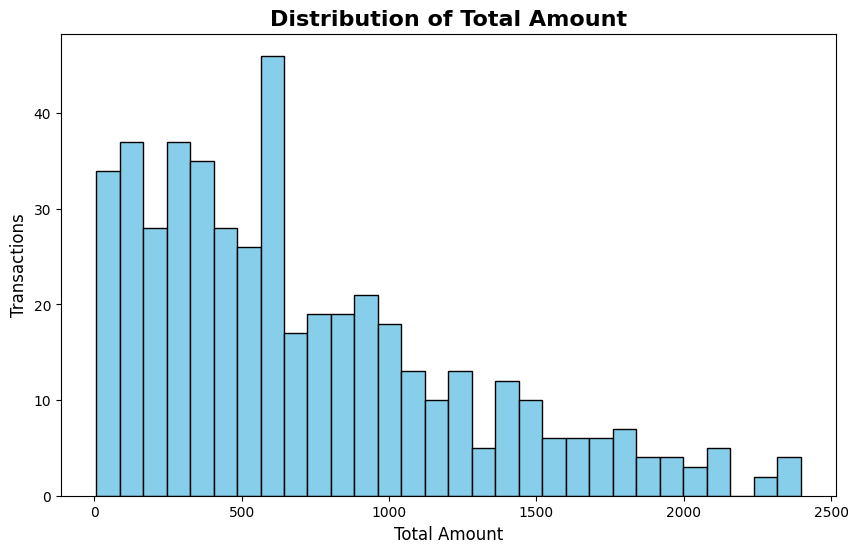

In [ ]:
# Create a histogram showing the distribution of total_amount
# Hint: Use plt.hist() or df_clean['total_amount'].hist()
# Make sure to add:
#   - A title
#   - X-axis label
#   - Y-axis label

# Your code here
plt.figure(figsize=(10, 6))
plt.hist(df_clean['total_amount'], bins=30, color='skyblue', edgecolor='black')
plt.title('Distribution of Total Amount', fontsize=16, fontweight='bold')
plt.xlabel('Total Amount', fontsize=12)
plt.ylabel('Transactions', fontsize=12)
plt.show()

### 6.2 Correlation Heatmap

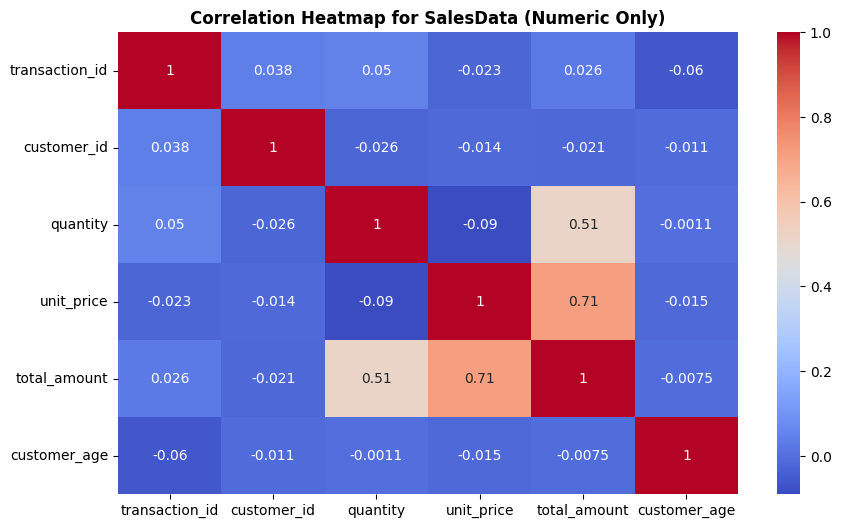

In [ ]:
# Create a correlation heatmap for numeric columns
# Hint: Use sns.heatmap() with df_clean.select_dtypes(include=[np.number]).corr()
# Make sure to add:
#   - A title
#   - Annotations (annot=True)
#   - A good color scheme (cmap='coolwarm' works well)

# Your code here
plt.figure(figsize=(10, 6))
sns.heatmap(
    df_clean.select_dtypes(include=[np.number]).corr(),
    annot=True,
    cmap='coolwarm'
)
plt.title('Correlation Heatmap for SalesData (Numeric Only)', fontsize=12, fontweight='bold')
plt.show()

### 6.3 Bar Chart: Transactions by Category

In [ ]:
# Get the order of categories by transaction counts
# category_order = df_clean['product_category'].value_counts().index

# Get the order of categories alphabetically
category_order = df_clean['product_category'].value_counts().sort_index().index

# print("Order of categories by product name (alphabetical):")
# print(list(category_order))

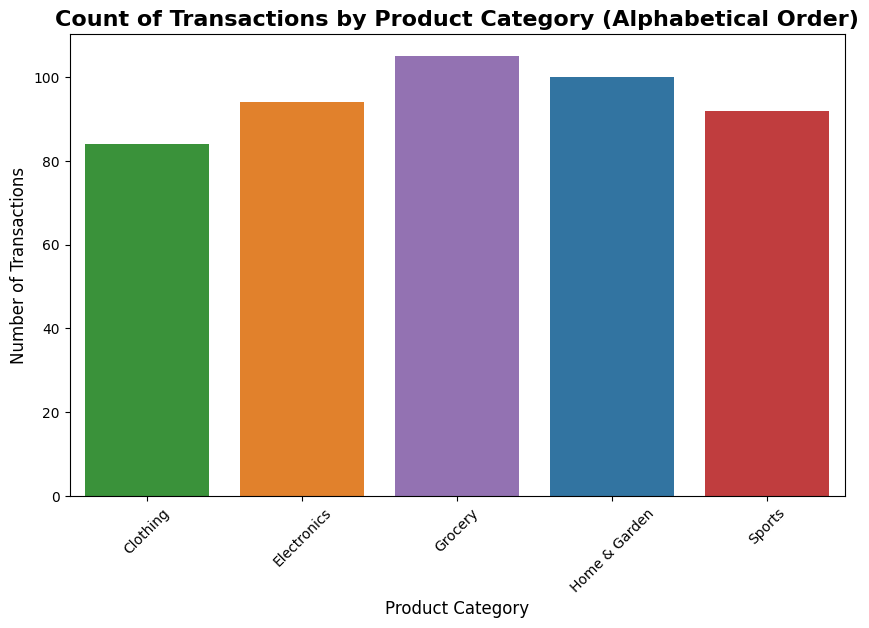

In [ ]:
# Create a bar chart showing the count of transactions per product_category
# Hint: Use df_clean['product_category'].value_counts().plot(kind='bar')
# Or use sns.countplot()
# Make sure to add:
#   - A title
#   - X-axis label
#   - Y-axis label

# Your code here
plt.figure(figsize=(10, 6))


sns.countplot(x='product_category', data=df_clean, hue='product_category', order=category_order)
plt.title('Count of Transactions by Product Category (Alphabetical Order)', fontsize=16, fontweight='bold')
plt.xlabel('Product Category', fontsize=12)
plt.ylabel('Number of Transactions', fontsize=12)
plt.xticks(rotation=45) # Rotate labels to prevent overlap
plt.show()

### 6.4 Box Plot: Total Amount by Category

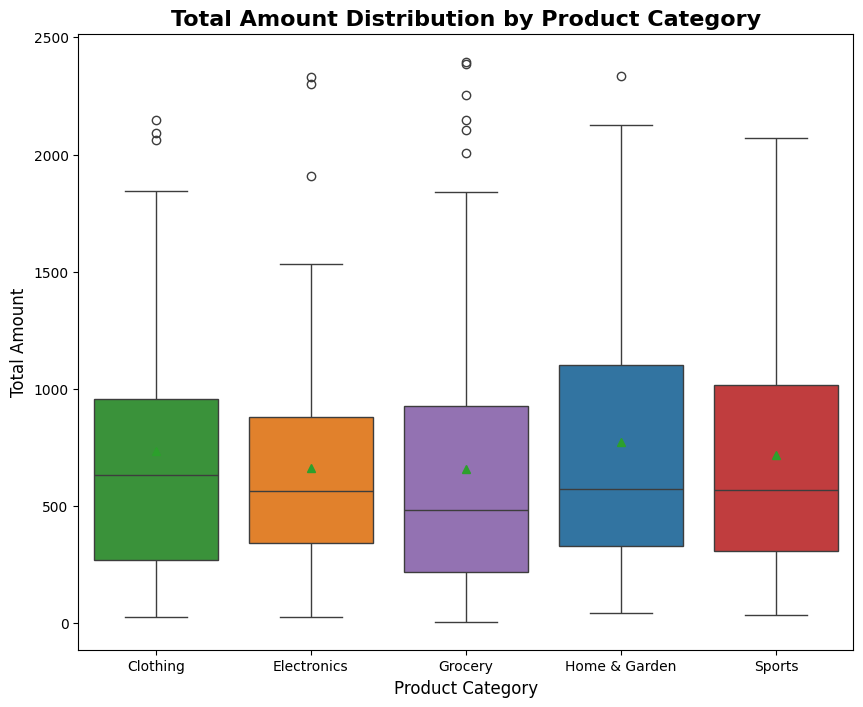

In [ ]:
# Create a box plot showing total_amount distribution for each product_category
# Hint: Use sns.boxplot(x='product_category', y='total_amount', data=df_clean)
# Make sure to add:
#   - A title
#   - Rotate x-axis labels if they overlap (plt.xticks(rotation=45))

# Your code here
plt.figure(figsize=(10, 8))
bp = sns.boxplot(x='product_category', y='total_amount', data=df_clean,
    hue='product_category',
    showmeans=True,
    order=category_order
)
plt.title('Total Amount Distribution by Product Category', fontsize=16, fontweight='bold')
plt.xlabel('Product Category', fontsize=12)
plt.ylabel('Total Amount', fontsize=12)
plt.show()

### Written Reflection
> **Please answer the questions below. They are a required part of the assignment!**

**Question 1:** Looking at your histogram, is the distribution of `total_amount` symmetric or skewed? What does this tell you about customer purchasing behavior?

**Question 2:** Looking at your correlation heatmap, which two variables have the strongest positive correlation? Does this relationship make logical sense?

*(Double-click here to write your answers)*

**Answer 1:** Instead of being symmetric, the distribution of total_amount is typically skewed.

A large number of customers make relatively small purchases.
Fewer transactions are for larger amounts. Only a small number of customers make very high-value purchases.

**Answer 2:** The two variables with the strongest positive correlation are most likely total_amount and unit_price. Yes, it does make logical sense.



---

## Part 7: Encode Categorical Columns

**The Problem:** Machine learning models need numbers, not text! We need to convert categorical columns into numeric format. But there are **two different methods** depending on the type of categorical data:

### Two Types of Categorical Data:

| Type | Description | Example | Encoding Method |
|------|-------------|---------|-----------------|
| **Ordinal** | Has a meaningful order | Bronze < Silver < Gold < Platinum | **Label Encoding** (0, 1, 2, 3) |
| **Nominal** | No inherent order | Red, Blue, Green | **One-Hot Encoding** (separate columns) |

### Your Dataset Has Both Types:
- `customer_tier` → **Ordinal** (Bronze < Silver < Gold < Platinum) → Use Label Encoding
- `product_category`, `payment_method`, `store_location`, `is_member` → **Nominal** → Use One-Hot Encoding

---

### 7a: Label Encoding (for Ordinal Data)

**Your Task:** Create a function that converts `customer_tier` to numbers while preserving the order.

| Tier | Encoded Value |
|------|---------------|
| Bronze | 0 |
| Silver | 1 |
| Gold | 2 |
| Platinum | 3 |

In [ ]:
def label_encode_ordinal(df, column, order):
    """
    Label encode an ordinal categorical column.

    Args:
        df (pd.DataFrame): The DataFrame
        column (str): The column name to encode
        order (list): The ordered list of categories (lowest to highest)
                      e.g., ['Bronze', 'Silver', 'Gold', 'Platinum']

    Returns:
        pd.DataFrame: DataFrame with the column label encoded
    """
    # IMPORTANT: Make a copy first!
    df_encoded = df.copy()

    # Your code here
    # Hint: Create a mapping dictionary like {'Bronze': 0, 'Silver': 1, ...}
    # Then use df_encoded[column].map(mapping)

    # Create a mapping dictionary
    mapping = {category: i for i, category in enumerate(order)}
    # print(f"Mapping Dictionary: {mapping}")

    # Apply the mapping
    df_encoded[column] = df_encoded[column].map(mapping)

    return df_encoded

In [ ]:
# ============================================================
# ⚠️  DO NOT MODIFY THIS CELL - VERIFICATION TESTS ONLY  ⚠️
# Just run this cell to check if your code is working.
# Hidden test cases depend on this exact structure.
# ============================================================

# Label encode customer_tier
tier_order = ['Bronze', 'Silver', 'Gold', 'Platinum']
df_label_encoded = label_encode_ordinal(df_clean, 'customer_tier', tier_order)

# Basic Verification
assert df_label_encoded is not None, "Function returned None"
assert df_label_encoded['customer_tier'].dtype in ['int64', 'int32', 'float64'], "customer_tier should be numeric"
assert df_label_encoded['customer_tier'].min() == 0, "Bronze should be encoded as 0"
assert df_label_encoded['customer_tier'].max() == 3, "Platinum should be encoded as 3"
print("[PASS] Part 7a Label Encoding Tests Passed!")

print("\nLabel Encoding Result:")
print(f"  Bronze (0): {(df_label_encoded['customer_tier'] == 0).sum()} customers")
print(f"  Silver (1): {(df_label_encoded['customer_tier'] == 1).sum()} customers")
print(f"  Gold (2): {(df_label_encoded['customer_tier'] == 2).sum()} customers")
print(f"  Platinum (3): {(df_label_encoded['customer_tier'] == 3).sum()} customers")

[PASS] Part 7a Label Encoding Tests Passed!

Label Encoding Result:
  Bronze (0): 201 customers
  Silver (1): 155 customers
  Gold (2): 84 customers
  Platinum (3): 35 customers


### 7b: One-Hot Encoding (for Nominal Data)

**Your Task:** Create a function that performs one-hot encoding on the nominal categorical columns.

### Example:
```
Before: product_category = "Electronics"
After:  product_category_Electronics = 1
        product_category_Clothing = 0
        product_category_Grocery = 0
        ...
```

In [ ]:
def one_hot_encode_nominal(df, columns):
    """
    One-hot encode the specified nominal categorical columns.

    Args:
        df (pd.DataFrame): The DataFrame
        columns (list): List of column names to encode

    Returns:
        pd.DataFrame: DataFrame with encoded columns
                      (original categorical columns should be removed)
    """
    # IMPORTANT: Make a copy first!
    df_encoded = df.copy()

    # Your code here
    # Hint: Use pd.get_dummies(df_encoded, columns=columns)
    df_encoded = pd.get_dummies(df_encoded, columns=columns, dtype=int)

    return df_encoded

In [ ]:
# ============================================================
# ⚠️  DO NOT MODIFY THIS CELL - VERIFICATION TESTS ONLY  ⚠️
# Just run this cell to check if your code is working.
# Hidden test cases depend on this exact structure.
# ============================================================

# One-hot encode nominal columns (use the label-encoded dataframe!)
nominal_columns = ['product_category', 'payment_method', 'store_location', 'is_member']
df_encoded = one_hot_encode_nominal(df_label_encoded, nominal_columns)

# Basic Verification
assert df_encoded is not None, "Function returned None"
assert 'product_category' not in df_encoded.columns, "Original 'product_category' column should be removed"
assert 'payment_method' not in df_encoded.columns, "Original 'payment_method' column should be removed"
# Check that new encoded columns exist
encoded_cols = [col for col in df_encoded.columns if 'product_category_' in col]
assert len(encoded_cols) > 0, "No encoded product_category columns found"
# Check that customer_tier is still numeric (from label encoding)
assert df_encoded['customer_tier'].dtype in ['int64', 'int32', 'float64'], "customer_tier should still be numeric"
print("[PASS] Part 7b One-Hot Encoding Tests Passed!")

print(f"\nAfter label encoding: {len(df_label_encoded.columns)} columns")
print(f"After one-hot encoding: {len(df_encoded.columns)} columns")
print(f"\nSample of new columns:")
for col in list(df_encoded.columns)[:10]:
    print(f"  - {col}")

[PASS] Part 7b One-Hot Encoding Tests Passed!

After label encoding: 13 columns
After one-hot encoding: 25 columns

Sample of new columns:
  - transaction_id
  - customer_id
  - date
  - product_name
  - quantity
  - unit_price
  - total_amount
  - customer_age
  - customer_tier
  - product_category_Clothing


### Written Reflection
> **Please answer the questions below. They are a required part of the assignment!**

**Question 1:** Why did we use **Label Encoding** for `customer_tier` but **One-Hot Encoding** for `product_category`? What's the key difference between these two columns?

**Question 2:** What would go wrong if we used Label Encoding for `product_category`? (Hint: Think about what the numbers would mean to the ML model.)

*(Double-click here to write your answers)*

**Answer 1:** We use Label-encoding for customer_tier because the column values are in logical order; but we use One-hot-encoding for column like product_category which has no logical ordering. The key difference between these two columns is logical order of values in respective columns.

**Answer 2:** Lets say, product_category has label-encocoding value 0,1,2,3 for their corresponding values. The Machine learning would think that if 'Electronics' is encoded as 0, 'Clothing' as 1, and 'Grocery' as 2, the model might think that 'Grocery' is 'greater than' or 'more important than' 'Electronics' or 'Clothing'. The ML model wll get confused.

---

## Part 8: Scale Numeric Columns

**The Problem:** Our numeric columns have very different scales. `customer_age` ranges from 10-100, while `total_amount` can be in the thousands. This can confuse ML models!

**Your Task:** Create a function that scales numeric columns to a 0-1 range using Min-Max scaling.

### Formula
```
scaled_value = (value - min) / (max - min)
```

### Example Verification
```python
df_scaled = scale_numeric_columns(df_encoded, ['customer_age', 'total_amount'])
print(df_scaled['customer_age'].min())  # Should be 0.0
print(df_scaled['customer_age'].max())  # Should be 1.0
```

In [ ]:
def scale_numeric_columns(df, columns):
    """
    Scale specified numeric columns to 0-1 range using Min-Max scaling.

    Formula: scaled = (value - min) / (max - min)

    Args:
        df (pd.DataFrame): The DataFrame
        columns (list): List of column names to scale

    Returns:
        pd.DataFrame: DataFrame with scaled columns
    """
    # IMPORTANT: Make a copy first!
    df_scaled = df.copy()

    # Your code here
    # For each column in columns:
    #   Apply the min-max scaling formula
    for col in columns:
        min_val = df_scaled[col].min()
        max_val = df_scaled[col].max()
        if (max_val - min_val) != 0: # Avoid division by zero for constant columns
            df_scaled[col] = (df_scaled[col] - min_val) / (max_val - min_val)
        else:
            df_scaled[col] = 0.0 # If all values are the same, scale to 0

    return df_scaled

In [ ]:
# ============================================================
# ⚠️  DO NOT MODIFY THIS CELL - VERIFICATION TESTS ONLY  ⚠️
# Just run this cell to check if your code is working.
# Hidden test cases depend on this exact structure.
# ============================================================

# Scale numeric columns
columns_to_scale = ['quantity', 'unit_price', 'total_amount', 'customer_age']
df_scaled = scale_numeric_columns(df_encoded, columns_to_scale)

# Basic Verification
assert df_scaled is not None, "Function returned None"
for col in columns_to_scale:
    assert df_scaled[col].min() >= 0, f"{col} has values below 0"
    assert df_scaled[col].max() <= 1, f"{col} has values above 1"
    assert abs(df_scaled[col].min() - 0) < 0.01, f"{col} minimum should be ~0"
    assert abs(df_scaled[col].max() - 1) < 0.01, f"{col} maximum should be ~1"
print("[PASS] Part 8 Tests Passed!")

print("\nScaled column ranges:")
for col in columns_to_scale:
    print(f"  {col}: [{df_scaled[col].min():.3f}, {df_scaled[col].max():.3f}]")

[PASS] Part 8 Tests Passed!

Scaled column ranges:
  quantity: [0.000, 1.000]
  unit_price: [0.000, 1.000]
  total_amount: [0.000, 1.000]
  customer_age: [0.000, 1.000]


### Written Reflection
> **Please answer the question below. It is a required part of the assignment!**

**Question:** Why is it important to scale features to a similar range before training a machine learning model? What could go wrong if we didn't scale?

**Answer:** Scaling features to a similar range helps many machine learning algorithms treat all inputs fairly and train reliably.

Scaling ensures that each feature contributes equally to the distance metric or the learning process, preventing features with naturally larger values from being perceived as more important simply due to their magnitude.

Without scaling, certain features with large‑range could dominate the learning process and degrades the model performance.

---

## Part 9: Prepare Final ML-Ready DataFrame

**The Problem:** We've done all the hard work! Now we need to put it all together and create the final DataFrame that the data science team will use in Unit 3.

**Your Task:** Create a function that:
1. Drops columns that aren't useful for ML (like `transaction_id`, `date`, `product_name`, `customer_id`)
2. Ensures ALL columns are numeric
3. Ensures there are NO missing values

### Example Verification
```python
final_df = prepare_ml_dataframe(df_scaled)
print(final_df.select_dtypes(exclude=[np.number]).columns)  # Should be empty
print(final_df.isnull().sum().sum())                        # Should be 0
```

In [ ]:
def prepare_ml_dataframe(df):
    """
    Prepare the final ML-ready DataFrame.

    Steps:
    1. Drop non-useful columns: transaction_id, date, product_name, customer_id
    2. Ensures ALL columns are numeric
    3. Ensures there are NO missing values

    Args:
        df (pd.DataFrame): The processed DataFrame

    Returns:
        pd.DataFrame: The final ML-ready DataFrame
    """
    # IMPORTANT: Make a copy first!
    final_df = df.copy()

    # Your code here
    # Step 1: Drop non-useful columns
    columns_to_drop = ['transaction_id', 'date', 'product_name', 'customer_id']
    final_df = final_df.drop(columns=columns_to_drop)

    # Step 2 & 3: All columns should already be numeric and have no missing values
    # due to previous cleaning, encoding, and scaling steps. We can re-verify if needed.
    # For this function, we'll assume the previous steps have correctly handled these.

    # non_numeric_columns = final_df.select_dtypes(exclude=[np.number]).columns.tolist()
    # print(f"Tota number of non-numeric columns: {len(non_numeric_columns)}")            # Should be empty
    # print(f"Total mumber of missing values: {final_df.isnull().sum().sum()}")           # Should be 0

    return final_df

In [ ]:
# ============================================================
# ⚠️  DO NOT MODIFY THIS CELL - VERIFICATION TESTS ONLY  ⚠️
# Just run this cell to check if your code is working.
# Hidden test cases depend on this exact structure.
# ============================================================

# Prepare the final ML-ready DataFrame
final_df = prepare_ml_dataframe(df_scaled)

# Basic Verification
assert final_df is not None, "Function returned None"
assert 'transaction_id' not in final_df.columns, "transaction_id should be dropped"
assert 'date' not in final_df.columns, "date should be dropped"
assert 'product_name' not in final_df.columns, "product_name should be dropped"
assert 'customer_id' not in final_df.columns, "customer_id should be dropped"
non_numeric = final_df.select_dtypes(exclude=[np.number]).columns.tolist()
assert len(non_numeric) == 0, f"All columns should be numeric, but found: {non_numeric}"
assert final_df.isnull().sum().sum() == 0, "There should be no missing values"
print("[PASS] Part 9 Tests Passed!")

print(f"\nFinal ML-Ready DataFrame:")
print(f"  Rows: {len(final_df)}")
print(f"  Columns: {len(final_df.columns)}")
print(f"  All numeric: True")
print(f"  Missing values: 0")

[PASS] Part 9 Tests Passed!

Final ML-Ready DataFrame:
  Rows: 475
  Columns: 21
  All numeric: True
  Missing values: 0


In [ ]:
# Preview the final DataFrame
final_df.head(10)

,quantity,unit_price,total_amount,customer_age,customer_tier,product_category_Clothing,product_category_Electronics,product_category_Grocery,product_category_Home & Garden,product_category_Sports,payment_method_Cash,payment_method_Credit Card,payment_method_Debit Card,payment_method_Mobile Payment,store_location_Airport,store_location_Downtown,store_location_Mall,store_location_Online,store_location_Suburb,is_member_No,is_member_Yes
0,0.75,0.257964,0.220132,0.211538,0,0,0,0,1,0,0,1,0,0,0,0,1,0,0,0,1
1,0.50,0.510184,0.320980,0.961538,3,0,1,0,0,0,0,0,1,0,0,0,0,0,1,0,1
2,0.00,0.518315,0.106940,0.307692,1,1,0,0,0,0,0,1,0,0,0,0,0,0,1,1,0
3,0.75,0.580126,0.486717,0.673077,1,0,1,0,0,0,0,1,0,0,0,0,1,0,0,0,1
4,0.50,0.574827,0.361098,0.076923,0,0,1,0,0,0,0,1,0,0,0,1,0,0,0,0,1
5,0.00,0.445218,0.091819,0.692308,0,0,0,0,0,1,1,0,0,0,1,0,0,0,0,0,1
6,0.25,0.390506,0.163603,1.000000,0,1,0,0,0,0,0,0,0,1,0,0,0,1,0,1,0
7,1.00,0.772173,0.807693,0.269231,2,0,0,0,1,0,1,0,0,0,0,0,0,1,0,1,0
8,0.00,0.588196,0.121397,0.307692,1,0,0,0,1,0,0,1,0,0,0,0,0,0,1,0,1
9,0.00,0.499970,0.103145,0.500000,1,0,0,0,1,0,0,0,1,0,0,0,1,0,0,0,1


---

## Final Summary

Run this cell to see a summary of your entire data pipeline!

In [ ]:
print("="*60)
print("DATA PIPELINE SUMMARY")
print("="*60)
print(f"\n1. ORIGINAL DATA")
print(f"   Rows: {len(df)}")
print(f"   Columns: {len(df.columns)}")
print(f"   Issues: Missing values, duplicates, messy text, outliers")

print(f"\n2. AFTER CLEANING")
print(f"   Rows: {len(df_clean)}")
print(f"   Missing values: {df_clean.isnull().sum().sum()}")
print(f"   Duplicates removed: {500 - len(df_clean)}")

print(f"\n3. AFTER ENCODING")
print(f"   Columns: {len(df_encoded.columns)}")
print(f"   Categorical columns converted to numeric")

print(f"\n4. AFTER SCALING")
print(f"   All numeric columns now in 0-1 range")

print(f"\n5. FINAL ML-READY DATA")
print(f"   Rows: {len(final_df)}")
print(f"   Columns: {len(final_df.columns)}")
print(f"   All numeric: True")
print(f"   Missing values: 0")
print(f"   Ready for machine learning: YES!")
print("\n" + "="*60)

DATA PIPELINE SUMMARY

1. ORIGINAL DATA
   Rows: 500
   Columns: 13
   Issues: Missing values, duplicates, messy text, outliers

2. AFTER CLEANING
   Rows: 475
   Missing values: 0
   Duplicates removed: 25

3. AFTER ENCODING
   Columns: 25
   Categorical columns converted to numeric

4. AFTER SCALING
   All numeric columns now in 0-1 range

5. FINAL ML-READY DATA
   Rows: 475
   Columns: 21
   All numeric: True
   Missing values: 0
   Ready for machine learning: YES!



---

## Final Written Reflection

> **Please answer the questions below. They are a required part of the assignment!**

**Question 1:** Looking back at this entire pipeline, which step do you think was the most important? Why?

**Question 2:** If ShopSmart gave you a brand new dataset next month, what would you do differently? What did you learn that would make the process faster?

**Question 3:** The final DataFrame is ready for machine learning. What kind of predictions do you think ShopSmart might want to make with this data? (There's no wrong answer - just think about what would be valuable for a retail business.)

*(Double-click here to write your answers)*

**Answer 1:** Data Cleaning is the most important step. I think this is the foundation for everything else. Without clean data, rest of the other steps will be no good. Missing values, duplicates, inconsistent formatting, and outliers can lead to inaccurate statistics and misleading visualizations here.

**Answer 2:** As long as the brand new dataset has same column names, I will point to that filepath and run this notebook to check the data quality, data cleaning, EDA, data encoding/scaling to prepare this dataset for ML by avoiding repetitive manual steps. This will make this data prepration task faster.

**Answer 3:** ShopSmart could use this prepared dataset to make these valuable predictions like sales forecasting, customer-churn predictions, product recommendations, and customer segmentation. These predictions can lead to increased revenue and enhance customer experience.

---

## Ready to Submit?

### Checklist:
- [ ] All **assert tests pass** (no errors when running the test cells)
- [ ] All **4 visualizations** are created and display correctly
- [ ] All **Written Reflections** are answered thoughtfully
- [ ] Code has **comments** explaining your logic
- [ ] No debugging print statements left in the code

### Submission:
Turn in your completed notebook on Canvas by **January 19th, 2025**.

Remember: You can resubmit after receiving feedback up until the due date!

---

*Great work making it through Unit 2! In Unit 3, you'll use this prepared data to build actual machine learning models.*

Yes I completed all Checklist.